# Survey of Superstaq 


Please visit the [Superstaq documentation](https://superstaq.readthedocs.io/en/latest/) for further elaboration on the topics discussed here as well as additional Superstaq offerings!

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Infleqtion/client-superstaq/blob/main/docs/source/optimizations/ibm/ibmq_dd.ipynb) [![Launch Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/Infleqtion/client-superstaq/HEAD?labpath=docs/source/optimizations/ibm/ibmq_dd.ipynb)

## Getting started: Imports and API Token

We begin with importing package requirements and setting up access to Superstaq. This tutorial uses `cirq-superstaq` and `qiskit-superstaq`, our Superstaq clients for Cirq and Qiskit respectively. You can install them and their relevant dependencies by running `pip install cirq-superstaq` and `pip install qiskit-superstaq`.

In [38]:
# Requirements to use cirq-superstaq
try:
    import cirq_superstaq as css
except ImportError:
    print("Installing cirq-superstaq...")
    %pip install --quiet 'cirq-superstaq[examples]'
    print("Installed cirq-superstaq.")
    print("You may need to restart the kernel to import newly installed packages.")
    import cirq_superstaq as css

import cirq

In [39]:
# Requirements to use qiskit-superstaq
try:
    import qiskit_superstaq as qss
except ImportError:
    print("Installing qiskit-superstaq...")
    %pip install --quiet 'qiskit-superstaq[examples]'
    print("Installed qiskit-superstaq.")
    print("You may need to restart the kernel to import newly installed packages.")
    import qiskit_superstaq as qss

import random

import numpy as np
import qiskit

To begin, we will stick with using `qiskit-superstaq`

All API calls to `superstaq` start with instantiating a provider in `qiskit-superstaq` with `SuperstaqProvider()`. Supply the Superstaq API token by providing the token as an argument of `qss.SuperstaqProvider()` or setting it as an environment variable (see [this guide](https://superstaq.readthedocs.io/en/latest/get_started/basics/basics_qss.html#Set-up-access-to-Superstaq%E2%80%99s-API)).

In [3]:
import os

superstaq_api_key = os.environ["SUPERSTAQ_API_KEY"]

In [40]:
# provider = qss.SuperstaqProvider(api_key=superstaq_api_key)
# OR
provider = qss.SuperstaqProvider()

## Account Information

The `provider` class gives you a means to retrieve information regarding your Superstaq account. You can use `provider` to retrieve your Superstaq balance like so:

In [41]:
provider.get_balance()

'1,752.31 credits'

If are interested in increasing your balance or have more information on your user role, please reach out to us at superstaq@infleqtion.com or join our [Slack workspace](https://join.slack.com/t/superstaq/shared_invite/zt-1wr6eok5j-fMwB7dPEWGG~5S474xGhxw).

## Backend Information
In addition to account information, the ``SuperstaqProvider`` object also gives you a list of all the devices and simulators to which you have access, as well as additional information about those backends.

* `get_targets()`: Retrieves a list of supported Superstaq targets. This method also accepts the following boolean keyword arguments to filter the backends returned: `simulator`, `supports_submit`, `supports_submit_qubo`, `supports_compile`, `available`, `retired`, and `accessible`.
* `backends()`: Retrieves a list of available backends. This method also accepts the same keyword arguments as mentioned above.
* `get_my_targets()`: Retrieves a filtered list of targets that are accessible to the user based on their user role permissions. This method is equivalent to `get_targets(accessible=True)`.
* `get_backend("<backend_name>")`: Select your target backend, where `<backend_name>` is the name of the desired backend
* `get_backend("<backend_name>").target_info()`: Retrieve information on your selected backend, such as number of qubits, native gate set

In [6]:
provider.get_targets()

[Target(target='alpine_ibex-q1_qpu', supports_submit=True, supports_submit_qubo=False, supports_compile=True, available=False, retired=False, accessible=True),
 Target(target='aqt_keysight_qpu', supports_submit=False, supports_submit_qubo=False, supports_compile=True, available=False, retired=False, accessible=False),
 Target(target='aqt_zurich_qpu', supports_submit=False, supports_submit_qubo=False, supports_compile=True, available=False, retired=False, accessible=False),
 Target(target='aws_dm1_simulator', supports_submit=True, supports_submit_qubo=False, supports_compile=True, available=True, retired=False, accessible=True),
 Target(target='aws_sv1_simulator', supports_submit=True, supports_submit_qubo=False, supports_compile=True, available=True, retired=False, accessible=True),
 Target(target='aws_tn1_simulator', supports_submit=True, supports_submit_qubo=False, supports_compile=True, available=True, retired=False, accessible=True),
 Target(target='cq_sqale_qpu', supports_submit=T

In [7]:
backend = provider.get_backend("ibmq_kingston_qpu")  # Selecting IBM's Kingston device
backend.target_info()

{'num_qubits': 156,
 'target': 'ibmq_kingston_qpu',
 'coupling_map': [[0, 1],
  [1, 0],
  [1, 2],
  [2, 1],
  [2, 3],
  [3, 2],
  [3, 4],
  [3, 16],
  [4, 3],
  [4, 5],
  [5, 4],
  [5, 6],
  [6, 5],
  [6, 7],
  [7, 6],
  [7, 8],
  [7, 17],
  [8, 7],
  [8, 9],
  [9, 8],
  [9, 10],
  [10, 9],
  [10, 11],
  [11, 10],
  [11, 12],
  [11, 18],
  [12, 11],
  [12, 13],
  [13, 12],
  [13, 14],
  [14, 13],
  [14, 15],
  [15, 14],
  [15, 19],
  [16, 3],
  [16, 23],
  [17, 7],
  [17, 27],
  [18, 11],
  [18, 31],
  [19, 15],
  [19, 35],
  [20, 21],
  [21, 20],
  [21, 22],
  [21, 36],
  [22, 21],
  [22, 23],
  [23, 16],
  [23, 22],
  [23, 24],
  [24, 23],
  [24, 25],
  [25, 24],
  [25, 26],
  [25, 37],
  [26, 25],
  [26, 27],
  [27, 17],
  [27, 26],
  [27, 28],
  [28, 27],
  [28, 29],
  [29, 28],
  [29, 30],
  [29, 38],
  [30, 29],
  [30, 31],
  [31, 18],
  [31, 30],
  [31, 32],
  [32, 31],
  [32, 33],
  [33, 32],
  [33, 34],
  [33, 39],
  [34, 33],
  [34, 35],
  [35, 19],
  [35, 34],
  [36, 21],
  

## Job Information
Jobs submitted through Superstaq contain the following information:

* `job_id()`: Unique identifier for the job.
* `status()`: Overall status of the job (Submitted, Queued, Running, Failed, Cancelled, or Done). Note that an `index` argument can be passed optionally to retreive the status of a specific job indexed by `index` in a batch job. 
* `backend()`: Device the job was run on.
* `result().get_counts()`: Counts from the result of the job run. Note that `result()` can take an `index` argument to retrieve a specific job result (corresponding to the circuit with the same `index`). It also optionally accepts a list of qubit indices to retrieve marginal counts on specific qubits via the `qubit_indices` argument of `result()`.
* `input_circuits()`: Retrieves original (i.e., not compiled) circuit(s) for job. Note this returns a list and you must specify an `index` if you want to retrieve a single/specific circuit.
* `compiled_circuits()`: Retrieves compiled circuit(s) from submitted job. Note this returns a list and you must specify an `index` if you want to retrieve a single/specific circuit.

Note that jobs live in our database for a limited amount of time. Typically, they have a lifespan of 1 year.

## Example 1: Compliation for QSCOUT

As seen in the target list in the previous cells, Superstaq supports various modalities. One exemplar trapped-ion hardware that is deeply optimized by Superstaq is the Quantum Scientific Computing Open User Testbed (QSCOUT), a quantum computing testbed at Sandia National Laboratories. In this example, we will explore a snippet of the features enabled by Superstaq for QSCOUT.

### Part A: Entangling basis compilation (continuously parameterized)

When compiling to the QSCOUT gateset, the type of entangling gate can be controlled. It is standard to expect a fixed angle entangling gate, however, Superstaq allows compilation to a continuously parameterized “arbitrary angle” entangling two-qubit gate to utilize during the compilation -- either a $XX$ or $ZZ$. Consider an example circuit such as:

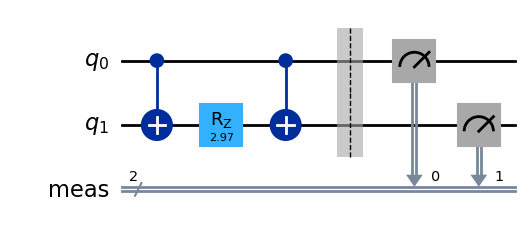

In [42]:
# Create circuit
rng = np.random.default_rng(random.getrandbits(128))
theta = rng.uniform(0, np.pi)
circuit = qiskit.QuantumCircuit(2)
circuit.cx(0, 1)
circuit.rz(theta, 1)
circuit.cx(0, 1)
circuit.measure_all()

# Visualize circuit
circuit.draw(output="mpl")

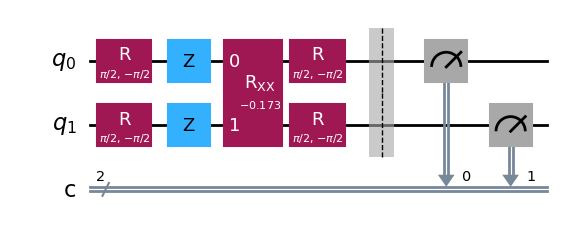

In [45]:
# Compile with XX entangling basis
compiler_output = provider.qscout_compile(circuit, base_entangling_gate="xx")

compiler_output.circuit.draw(output="mpl")

By default, the $XX$ interaction is used, and we observe that it uses the $R_{XX}$ gate as the base entangling gate in the compiled circuit. Similarly, let's take a look at the compiled circuit if we now specify the compiler to use the $ZZ$ interaction instead:

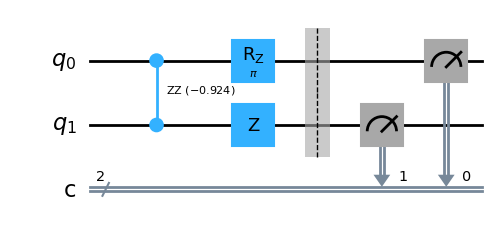

In [10]:
# Compile with ZZ entangling basis
compiler_output = provider.qscout_compile(circuit, base_entangling_gate="zz")

compiler_output.circuit.draw(output="mpl")

### Part B: Just-a-quantum-assembly-language (Jaqal) translation

The resulting output is now a circuit compiled and optimized to QSCOUT's native operations. But there's more! With Superstaq's compilation, users can also get the corresponding Jaqal (see [Just another quantum assembly language](https://arxiv.org/abs/2008.08042)) program for their compiled circuit. The Jaqal program is a useful representation that highlights the sequence of pulse level single and two-qubit gates  that have to be executed on the trapped ions to realize the user's circuit. To view the jaqal program, users simply have to call `jaqal_program` on their `compiler_output`, and print to list it in a readable format. 

In [11]:
# Get jaqal program and draw circuit
print(compiler_output.jaqal_program)

from qscout.v1.std usepulses *

register allqubits[2]

prepare_all
ZZ allqubits[0] allqubits[1] -0.9241648882694551
<
	Rz allqubits[0] 3.141592653589791
	Rz allqubits[1] -3.141592653589793
>
measure_all



### Part C: SWAP mirroring

In addition to specifying the type of base entangling gate to use for the compilation and optimization, we can also specify whether to use swap mirroring to help reduce the two-qubit gate overhead of the circuit. By default, it is not enabled; but we will see the differences in circuit compilation by compiling to a random quantum volume model circuit. You can learn more about quantum volume and randomized circuits [here](https://arxiv.org/abs/1811.12926), but a brief overview is illustrated by this: 

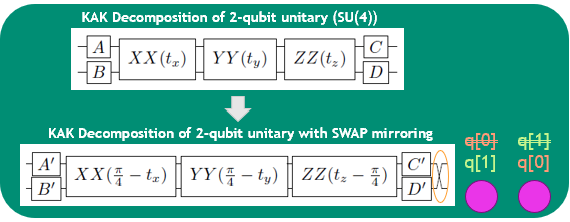

Leads to -> ~17% less MS time after SWAP insertions (or, more small-rotation discrete entanglers)

In [12]:
circ = qiskit.circuit.library.quantum_volume(num_qubits=2, depth=3, seed=123)
circ.measure_all()

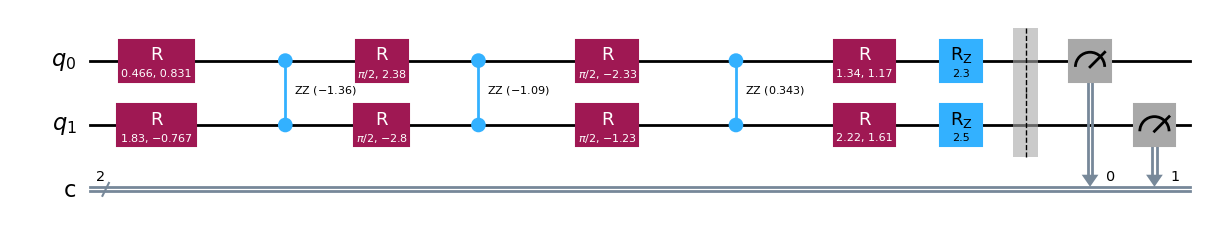

In [13]:
# Compile with no swap mirroring
output_nsm = provider.qscout_compile(circ, mirror_swaps=False, base_entangling_gate="zz")

# Visualize the circuit
circ_nsm = output_nsm.circuit
circ_nsm.draw("mpl", fold=-1)

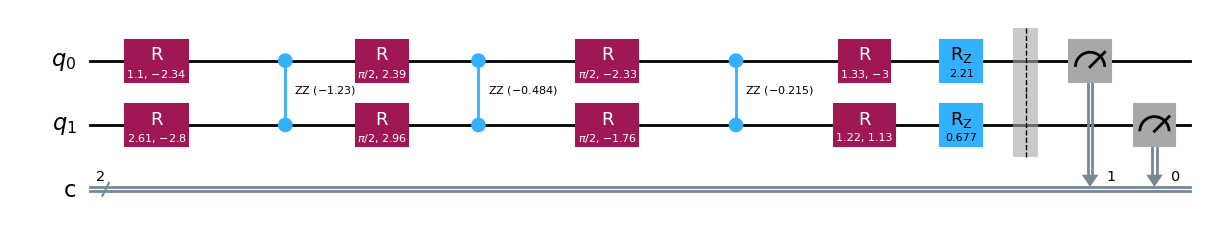

In [14]:
# Compile with swap mirroring
output_wsm = provider.qscout_compile(circ, mirror_swaps=True, base_entangling_gate="zz")

# Visualize the circuit
circ_wsm = output_wsm.circuit
circ_wsm.draw("mpl", fold=-1)

In [15]:
# Return final qubit map for non swap-mirrored circuit
map_nsm = output_nsm.final_logical_to_physical
print("Non swap-mirrored mapping:", map_nsm)

# Return final qubit map for swap-mirrored circuit
map_wsm = output_wsm.final_logical_to_physical
print("Swap-mirrored mapping:", map_wsm)

Non swap-mirrored mapping: {0: 0, 1: 1}
Swap-mirrored mapping: {0: 1, 1: 0}


#### Highlight: Swap mirroring decreased the angle of the entangling gate of compiled Quantum Volume circuit, producing a more efficient implementation!

# Example 2: Compliation for IBM (dynamical decoupling)

There are many possible ways to determine how and where to place error mitigation dynamical decoupling (DD) sequences within a qubit idling window. We refer to these approaches as strategies. If users want more control over the way Superstaq applies DD, they can specify their desired strategy. Superstaq supports the following dynamical decoupling strategies:

* **Standard**: Places a single DD sequence in each idle window.<br>
* **Syncopated**: Places DD pulses at fixed time intervals, alternating between pulses on neighboring qubits in order to mitigate parasitic ZZ coupling errors.<br>
* **Adaptive** (default): Dynamically spaces DD pulses across idle windows with awareness of neighboring qubits to achieve the parasitic ZZ coupling mitigation of the "syncopated" strategy with fewer pulses and less discretization error.<br>

Users have the ability to specify the dynamical decoupling strategy desired via the keyword argument `dd_strategy`.

All of the above strategies, by default, use the XX sequence: a sequence consisting of a pair of equally-spaced X gates. this can be changed via the `dd_sequence` keyword argument.

In this example, we will be creating a pair of 8-qubit GHZ circuits, which we generate below:

In [16]:
n_qubits = 8
circuit = qiskit.QuantumCircuit(8)

circuit.h(0)
for i in range(1, circuit.num_qubits):
    circuit.cx(0, i)

for i in range(circuit.num_qubits - 1):
    circuit.cx(-1, i)

circuit.measure_all()

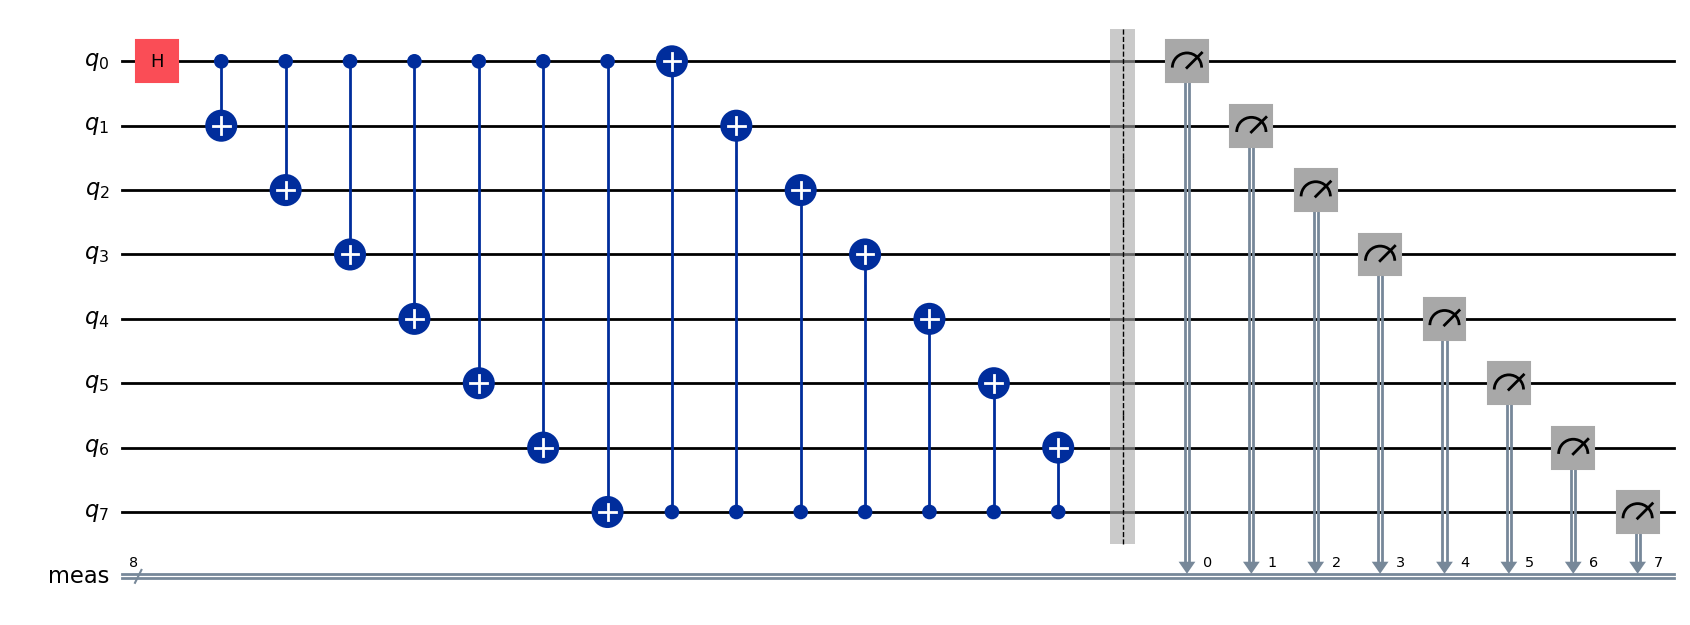

In [17]:
circuit.draw("mpl")

In [18]:
backend = provider.get_backend("ibmq_fez_qpu")
backend_target = backend.target

First, let us look at the pulse level circuit with no DD:

In [19]:
compiler_output = backend.compile(circuit, dynamical_decoupling=False, random_seed=123)

In [20]:
custom_style = {"formatter.general.fig_width": 45, "formatter.general.fig_unit_height": 1}
style = qiskit.visualization.timeline.IQXStandard(**custom_style)

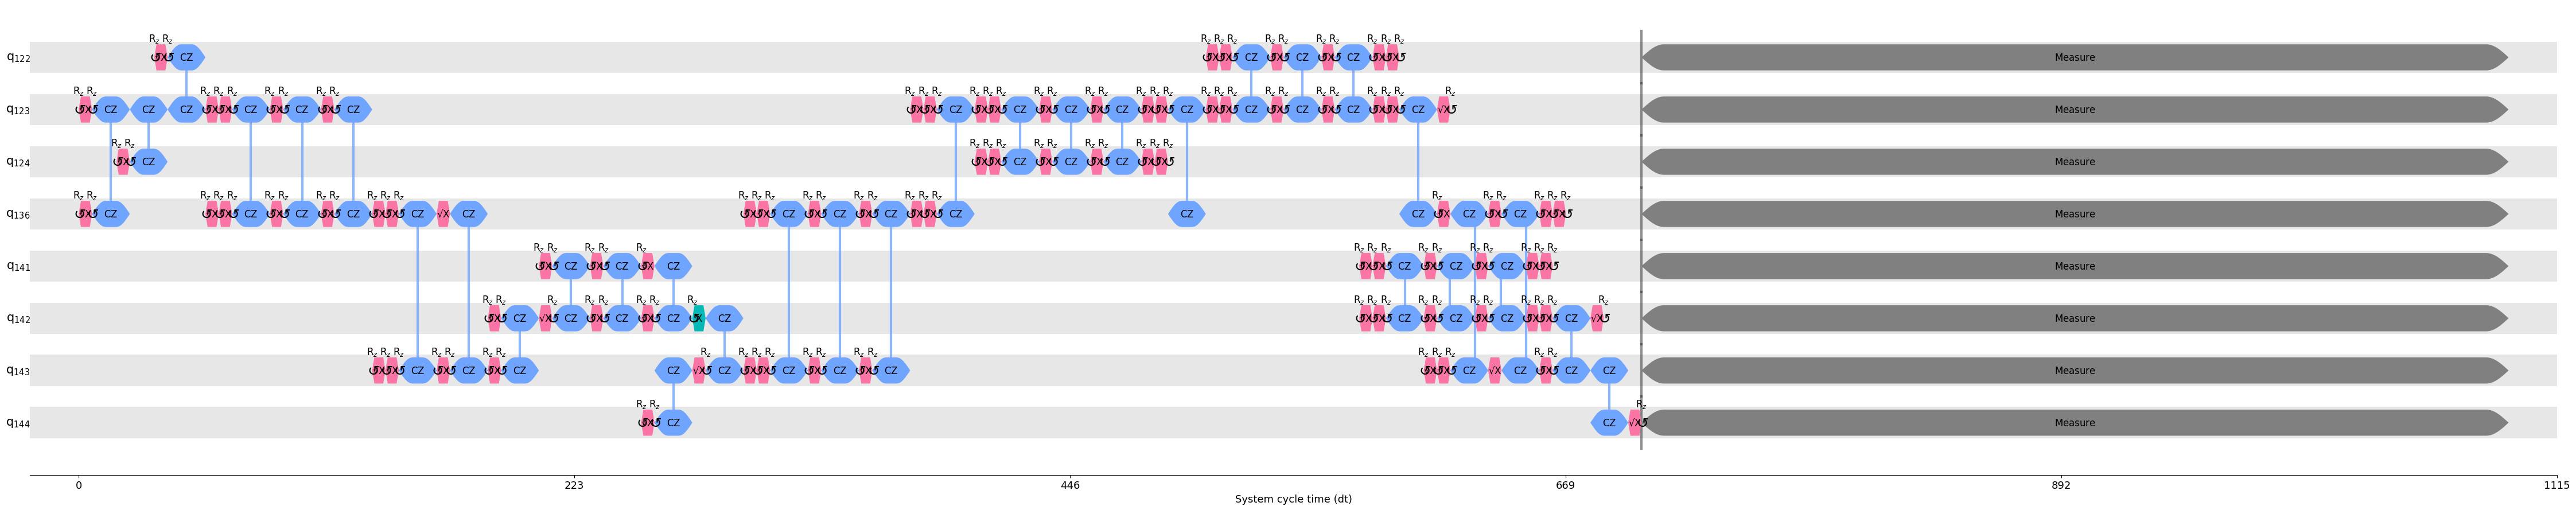

In [21]:
pulse_circuit = compiler_output.pulse_gate_circuit
pulse_circuit.duration = pulse_circuit.estimate_duration(target=backend_target, unit="dt")

qiskit.visualization.timeline_drawer(
    pulse_circuit,
    idle_wires=False,
    style=style,
    target=backend_target,
)

Next we'll compile the same circuit using the "standard" dynamical decoupling strategy. This strategy inserts pairs of X gates into the long idle periods on each qubit in order to suppress local dephasing.

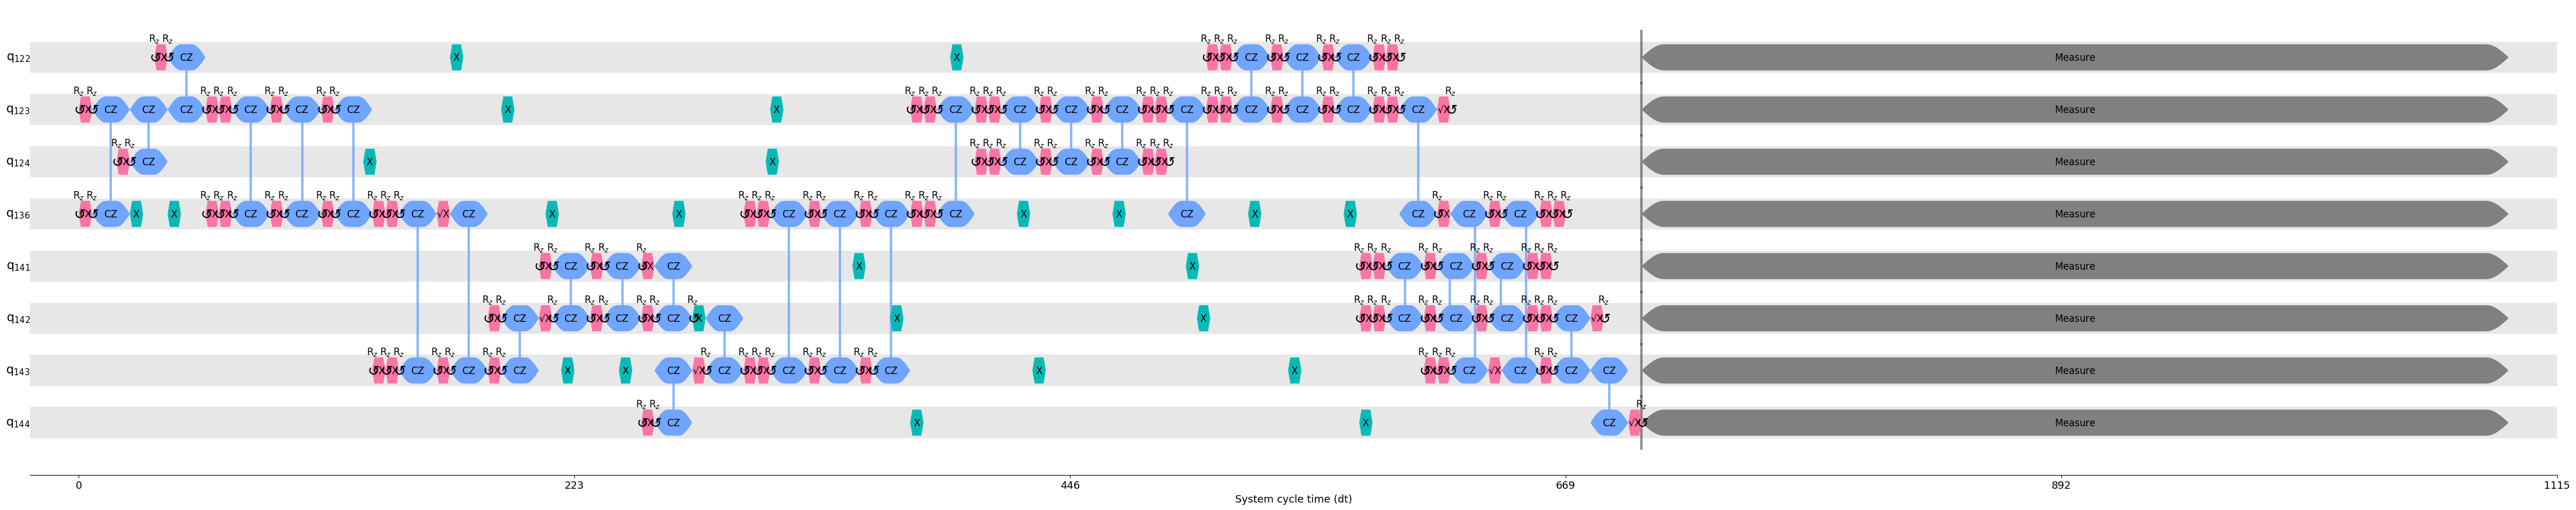

In [22]:
compiler_output = backend.compile(
    circuit, dd_strategy="standard", dynamical_decoupling=True, random_seed=123
)
pulse_circuit = compiler_output.pulse_gate_circuit
pulse_circuit.duration = pulse_circuit.estimate_duration(target=backend_target, unit="dt")

qiskit.visualization.timeline_drawer(
    pulse_circuit,
    idle_wires=False,
    style=style,
    target=backend_target,
)

Below, we compile with dynamical decoupling using the "syncopated" strategy. With this strategy many equally-spaced DD pulses can be inserted into the same idle period. Their timing relative to those on neighboring qubits can suppress errors due to parasitic coupling in addition to local dephasing.

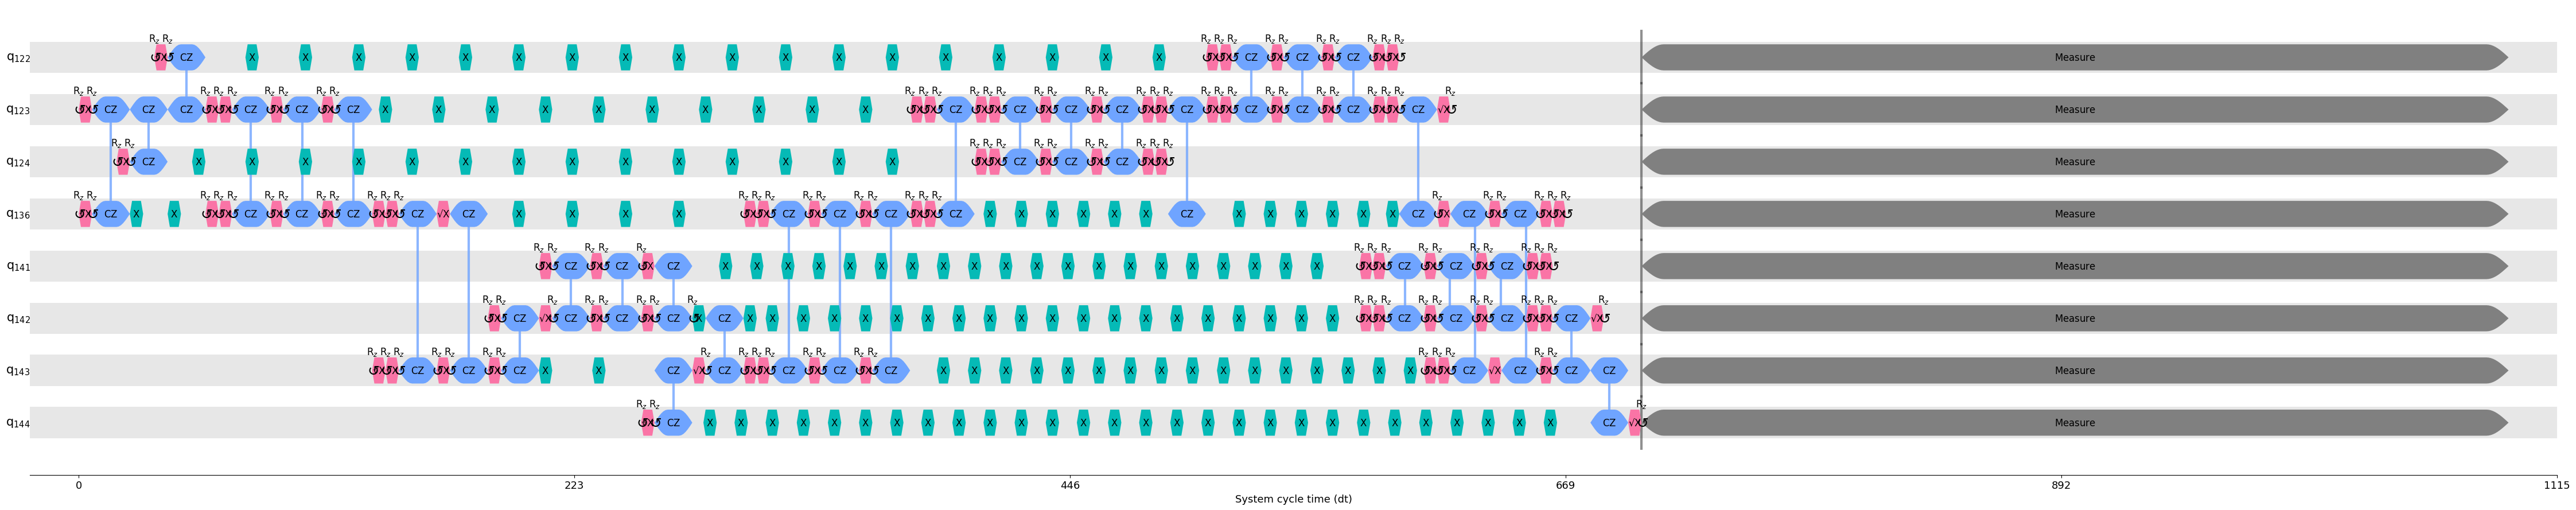

In [23]:
compiler_output = backend.compile(
    circuit, dd_strategy="syncopated", dynamical_decoupling=True, random_seed=123
)
pulse_circuit = compiler_output.pulse_gate_circuit
pulse_circuit.duration = pulse_circuit.estimate_duration(target=backend_target, unit="dt")

qiskit.visualization.timeline_drawer(
    pulse_circuit,
    idle_wires=False,
    style=style,
    target=backend_target,
)

Finally, we compile with dynamical decoupling using Superstaq's default "adaptive" strategy. This will adaptively space DD pulses in order to achieve the error suppression of the prior strategy with far fewer pulses.

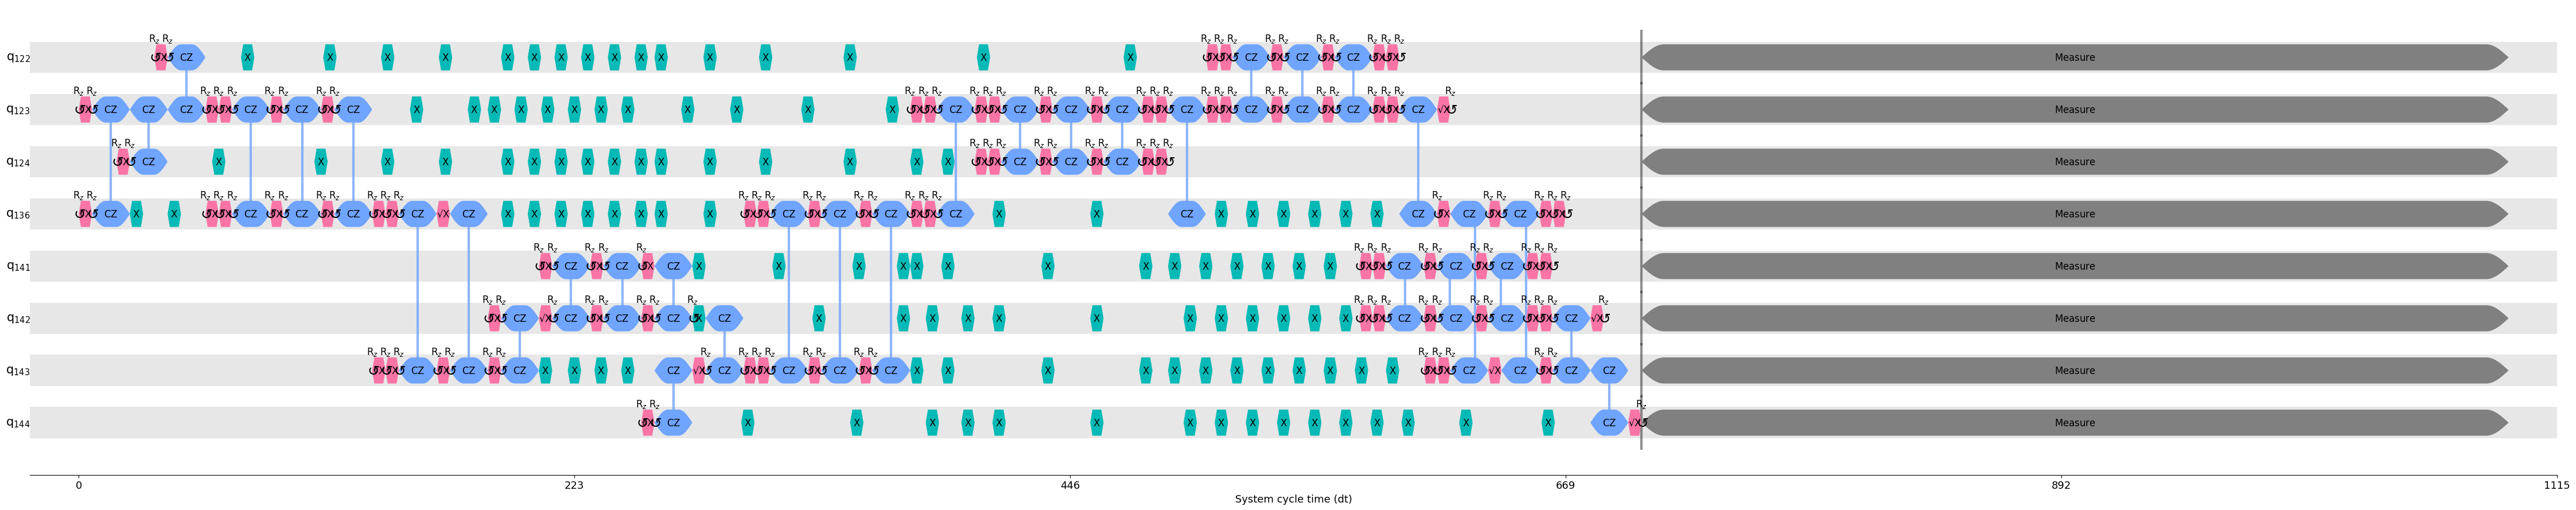

In [24]:
compiler_output = backend.compile(
    circuit, dd_strategy="adaptive", dynamical_decoupling=True, random_seed=123
)
pulse_circuit = compiler_output.pulse_gate_circuit
pulse_circuit.duration = pulse_circuit.estimate_duration(target=backend_target, unit="dt")

qiskit.visualization.timeline_drawer(
    pulse_circuit, idle_wires=False, style=style, target=backend_target
)

#### Highlight: Error mitigation is easy to implement. Advanced users are able to customize configuration. Dynamical decoupling does not add to compiled circuit runtime as gates are placed within existing circuit idling windows. 

# Example 3: Compilation for Sqale (global gates and grid qubits)

Superstaq, naturally, supports Infleqtion's gate-based neutral atom quantum computer, [Sqale](https://arxiv.org/html/2408.08288v2) via cloud access. Neutral atom machines, like all modalities, have their own quirks and unique gatesets. For Sqale, its universal gateset consists of a GR gate (global rotation gate), Rz rotation gate, and the two-qubit CZ (controlled-Z) gate. Sqale's grid connectivity is understood by Superstaq and compiled accordingly. Moreover, Sqale supports atom motion, enabling any-to-any connectivity and Superstaq is able to parse such operations as well.  

To showcase `cirq-superstaq` as well, we shall go over a workflow with it. However, Superstaq maintains as close feature parity between the different packages so the `qiskit` variant is not any dissimilar!

In [46]:
superstaq_service = css.Service()

For demonstrative purposes, consider an arbitrary circuit in `cirq`:

In [26]:
qubits = cirq.LineQubit.range(4)

In [48]:
circuit1 = cirq.testing.random_circuit(qubits, n_moments=5, op_density=0.5)
circuit1

┌──────┐               ┌──┐
0: ────iSwap─────────@────────@─────
       │             │        │
1: ────┼────H────────┼────────┼Z────
       │             │        │
2: ────┼─────────────@────────┼─────
       │                      │
3: ────iSwap─────S────────────@─────
      └──────┘               └──┘

### Single Circuit Compilation

We will now compile the above circuit onto Sqale's native gateset and visualize the differences by drawing the compiled circuit

In [49]:
compiler_output = superstaq_service.cq_compile(circuit1)

In [50]:
compiler_output.circuit

0: ────RGate(0.5π, 0)──────────RGate(0.5π, 0.5π)───@───RGate(-0.5π, 0.5π)───S^-1───RGate(0.5π, 0.5π)───@───RGate(-0.5π, 0.5π)───S^-1───RGate(0.5π, 0.5π)───@───@───Z──────
       │                       │                   │   │                           │                   │   │                           │                   │   │
1: ────#2──────────────────────#2──────────────────@───#2───────────────────S──────#2──────────────────@───#2───────────────────S^-1───#2──────────────────┼───@───S──────
       │                       │                       │                           │                       │                           │                   │
2: ────#3──────────────────────#3──────────────────────#3──────────────────────────#3──────────────────────#3──────────────────────────#3──────────────────┼──────────────
       │                       │                       │                           │                       │                           │                   │
3: ────#4──────────────────────#4──────────────────────#4──────────────────────────#4──────────────────────#4──────────────────────────#4──────────────────┼──────────────
       │                       │                       │                           │                       │                           │                   │
4: ────#5──────────────────────#5──────────────────────#5──────────────────────────#5──────────────────────#5──────────────────────────#5──────────────────┼──────────────
       │                       │                       │                           │                       │                           │                   │
5: ────#6──────────────────────#6──────────────────────#6──────────────────────────#6──────────────────────#6──────────────────────────#6──────────────────┼──────────────
       │                       │                       │                           │                       │                           │                   │
6: ────#7──────────────────────#7──────────────────────#7──────────────────────────#7──────────────────────#7──────────────────────────#7──────────────────┼──────────────
       │                       │                       │                           │                       │                           │                   │
7: ────#8──────────────────────#8──────────────────────#8──────────────────────────#8──────────────────────#8──────────────────────────#8──────────────────┼───────S^-1───
       │                       │                       │                           │                       │                           │                   │
8: ────#9───────────────S^-1───#9──────────────────────#9──────────────────────────#9──────────────────────#9──────────────────────────#9──────────────────@───────S──────
       │                       │                       │                           │                       │                           │
9: ────#10─────────────────────#10─────────────────────#10─────────────────────────#10─────────────────────#10─────────────────────────#10────────────────────────────────
       │                       │                       │                           │                       │                           │
10: ───#11─────────────────────#11─────────────────────#11─────────────────────────#11─────────────────────#11─────────────────────────#11────────────────────────────────
       │                       │                       │                           │                       │                           │
11: ───#12─────────────────────#12─────────────────────#12─────────────────────────#12─────────────────────#12─────────────────────────#12────────────────────────────────
       │                       │                       │                           │                       │                           │
12: ───#13─────────────────────#13─────────────────────#13─────────────────────────#13─────────────────────#13─────────────────────────#13──

If you would like to compile (or submit) on a different number of qubits, this can be done via the ```grid_shape``` option. This simply sets the shape of the rectangular qubit grid. However, specifying a grid that is incompatible with Sqale's current capabilities will result in an error when submitting.

In [30]:
example_circuit = cirq.Circuit(
    cirq.H.on_each(*qubits[1:]),
    cirq.CNOT(qubits[1], qubits[0]),
    cirq.measure(qubits[0]),
    cirq.measure(qubits[1]),
)
print(example_circuit)

0: ───────X───M───
          │
1: ───H───@───M───

2: ───H───────────

3: ───H───────────


In [31]:
new_compiler_output = superstaq_service.cq_compile(example_circuit, grid_shape=(4, 1))
new_compiler_output.circuit

(0, 0): ───RGate(0.5π, -0.5π)───@───RGate(-0.5π, π)───S───RGate(0.5π, π)───────M('q(0)')───
           │                    │   │                     │
(1, 0): ───#2───────────────────@───#2────────────────────#2───────────────────M('q(1)')───
           │                        │                     │
(2, 0): ───#3───────────────────────#3────────────────────#3───────────────Z───────────────
           │                        │                     │
(3, 0): ───#4───────────────────────#4────────────────────#4───────────────Z───────────────

### Multiple circuit compilation

If you would like to compile a batch of circuits in one-go, `cirq-superstaq` (& `qiskit-superstaq`) accepts a list of circuits as well. To illustrate this, let us first create a different example circuit, and compile both circuits we have created so far at the same time. 

In [32]:
circuit2 = cirq.Circuit(
    cirq.H(qubits[0]),
    cirq.X(qubits[1]),
    cirq.QubitPermutationGate([1, 0]).on(qubits[0], qubits[1]),
    cirq.measure(qubits[1]),
)
circuit2

0: ───H───[0>1]───────
          │
1: ───X───[1>0]───M───

In [33]:
compiler_output = superstaq_service.cq_compile([circuit1, circuit2], grid_shape=(3, 3))

In [34]:
compiler_output.circuits[0]

(0, 0): ───RGate(-0.5π, π)──────────RGate(0.5π, π)───────RGate(-0.5π, π)───────RGate(0.5π, π)───
           │                        │                    │                     │
(0, 1): ───#2───────────────────────#2───────────────────#2────────────────────#2───────────────
           │                        │                    │                     │
(0, 2): ───#3───────────────────────#3───────────────────#3────────────────────#3───────────────
           │                        │                    │                     │
(1, 0): ───#4───────────────────────#4───────────────────#4────────────────────#4───────────────
           │                        │                    │                     │
(1, 1): ───#5───────────────────────#5───────────────────#5────────────────────#5───────────────
           │                        │                    │                     │
(1, 2): ───#6───────────────────────#6───────────────────#6────────────────────#6───────────────
           │                        │                    │                     │
(2, 0): ───#7───────────────────────#7───────────────────#7────────────────────#7───────────────
           │                        │                    │                     │
(2, 1): ───#8────────────────S^-1───#8───────────────@───#8────────────────S───#8───────────────
           │                        │                │   │                     │
(2, 2): ───#9───────────────────────#9───────────────@───#9────────────────────#9───────────────

In [35]:
compiler_output.circuits[1]

(0, 0): ───RGate(-0.5π, 0)───S───RGate(0.5π, 0)───[0>1]───Z───────────────
           │                     │                │
(0, 1): ───#2────────────────Z───#2───────────────[1>0]───────M('q(1)')───
           │                     │
(0, 2): ───#3────────────────────#3───────────────────────────────────────
           │                     │
(1, 0): ───#4────────────────────#4───────────────────────────────────────
           │                     │
(1, 1): ───#5────────────────────#5───────────────────────────────────────
           │                     │
(1, 2): ───#6────────────────────#6───────────────────────────────────────
           │                     │
(2, 0): ───#7────────────────────#7───────────────────────────────────────
           │                     │
(2, 1): ───#8────────────────────#8───────────────────────────────────────
           │                     │
(2, 2): ───#9────────────────────#9───────────────────────────────────────

## Circuit Submission

All the functionalities we have seen so far can be applied to submit single- or multi-circuit jobs. For example, the code below will submit both the circuits from earlier to the noiseless Sqale simulator. If you would like to run on the Sqale QPU, change the ```target``` argument in ```create_job()``` from ```cq_sqale_simulator``` to ```cq_sqale_qpu```. It is recommended to first submit to the simulator for testing to ensure your code runs before submitting to the Sqale QPU. 

In [36]:
job_css = superstaq_service.create_job(
    [example_circuit, circuit2], repetitions=100, target="cq_sqale_simulator"
)
result_job_1 = job_css.counts(index=0)
result_job_2 = job_css.counts(index=1)

print(f"Counts from cirq-superstaq submission for 1st circuit: {result_job_1}")
print(f"Counts from cirq-superstaq submission for 2nd circuit: {result_job_2}")

Counts from cirq-superstaq submission for 1st circuit: {'11': 49, '00': 51}
Counts from cirq-superstaq submission for 2nd circuit: {'1': 45, '0': 55}


If you would like to submit circuits to a noisy simulator to see the effects of noise on your simulated measurements without submitting to an actual device, you can additionally pass the argument ```method=noise-sim``` in ```create_job()```. Here's an example code snippet for a single-circuit simulation:

In [37]:
job_css = superstaq_service.create_job(
    example_circuit, repetitions=100, target="cq_sqale_simulator", method="noise-sim"
)
result_css = job_css.counts(0)
print(f"Counts from noisy cirq-superstaq submission: {result_css}")

Counts from noisy cirq-superstaq submission: {'00': 41, '11': 54, '10': 2, '01': 3}


#### Highlight: Superstaq allows for easy compilation and noisy simulation of circuits targeted to a wide range of qubit technologies!